In [1]:
# Install dependencies (run once)
import subprocess
import sys

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "astropy",
    "astroquery",
    "requests",
    "tqdm",
    "scipy",
    "lxml",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Dependencies installed successfully.")

Dependencies installed successfully.


In [2]:
# Imports and configuration
import json
import math
import re
import time
import warnings
from io import BytesIO
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from tqdm.auto import tqdm

from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.ipac.irsa import Irsa
from scipy import ndimage as ndi

warnings.filterwarnings("ignore")

# ----------------------------
# User configuration
# ----------------------------
OUTDIR = Path("cosmos_irsa_auto")
FITSDIR = OUTDIR / "fits"
NPYDIR = OUTDIR / "npy"
MASKEDNPYDIR = OUTDIR / "masked_npy"
MASKDIR = OUTDIR / "masks"
METADIR = OUTDIR / "metadata"
PLOTDIR = OUTDIR / "qa_plots"
XMLDIR = OUTDIR / "xml"

for d in [OUTDIR, FITSDIR, NPYDIR, MASKEDNPYDIR, MASKDIR, METADIR, PLOTDIR, XMLDIR]:
    d.mkdir(parents=True, exist_ok=True)

# How many accepted cutouts you want in this run
TARGET_N = 50

# COSMOS ACS cutout size
CUTOUT_SIZE_ARCSEC = 5.0
DEFAULT_PIXEL_SCALE_ARCSEC = 0.03
EXPECTED_SIZE_PIX = int(round(CUTOUT_SIZE_ARCSEC / DEFAULT_PIXEL_SCALE_ARCSEC))

# COSMOS field centre
COSMOS_RA_CENTER = 150.1192
COSMOS_DEC_CENTER = 2.2058
SEARCH_RADIUS_DEG = 0.45

# IRSA COSMOS ACS I-band photometry catalog
CATALOG_NAME = "acs_iphot_sep07"

# Broad catalog cuts
KEEP_FLAGS_MAX = 3
MAG_AUTO_MIN = 18.0
MAG_AUTO_MAX = 25.5
FLUX_RADIUS_MIN = 2.0
FLUX_RADIUS_MAX = 40.0
ELONGATION_MAX = 3.0

# IRSA cutout service
IRSA_CUTOUT_URL = "https://irsa.ipac.caltech.edu/cgi-bin/Cutouts/nph-cutouts"
REQUEST_DELAY_SEC = 1.1
TIMEOUT_SEC = 120
MAX_DOWNLOAD_ATTEMPTS = 5000

# We only want the ACS mosaic product
REQUIRE_ACS_PRODUCT = True
ACS_PRODUCT_HINTS = ["acs_mosaic_2.0", "acs", "mosaic", "hst"]
REJECT_URL_HINTS = [
    "subaru", "cfht", "kpno", "sdss", "irac", "mips",
    "galex", "xmm", "vla", "nicmos", "wfpc"
]

# Lightweight image QA
MIN_FINITE_FRACTION = 0.98
MIN_STD = 0.003
MAX_EDGE_ABS_MEAN = 0.50
MIN_MAIN_FLUX_FRACTION = 0.20
MIN_COMPONENT_PIXELS = 20
SEG_NSIGMA = 3.0

# Optional masking
SAVE_MASKS = True
SAVE_MASKED_NPY = True
EXPORT_MASKED_FOR_LENSTRONOMY = False
MASK_DILATION_ITERS = 3

# Resume behavior
OVERWRITE_EXISTING = False

RNG = np.random.default_rng(42)
SESSION = requests.Session()
SESSION.headers.update({"User-Agent": "cosmos-irsa-lenstronomy-pipeline/1.0"})

print("Output folder:", OUTDIR.resolve())
print("Target accepted cutouts:", TARGET_N)
print("Cutout size (arcsec):", CUTOUT_SIZE_ARCSEC)
print("Expected size (pixels):", EXPECTED_SIZE_PIX)
print("Catalog:", CATALOG_NAME)

Output folder: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto
Target accepted cutouts: 50
Cutout size (arcsec): 5.0
Expected size (pixels): 167
Catalog: acs_iphot_sep07


In [3]:
# Query the COSMOS ACS photometry catalog
center = SkyCoord(ra=COSMOS_RA_CENTER * u.deg, dec=COSMOS_DEC_CENTER * u.deg)

requested_columns = [
    "ra",
    "dec",
    "mu_class",
    "mag_auto",
    "flux_radius",
    "elongation",
    "flags",
    "a_world",
    "b_world",
]

colinfo = Irsa.list_columns(CATALOG_NAME)
available_columns = list(colinfo.keys())
valid_columns = [c for c in requested_columns if c in available_columns]
missing_columns = [c for c in requested_columns if c not in available_columns]

print("Using columns:", valid_columns)
if missing_columns:
    print("Missing columns:", missing_columns)

cat_table = Irsa.query_region(
    coordinates=center,
    catalog=CATALOG_NAME,
    spatial="Cone",
    radius=SEARCH_RADIUS_DEG * u.deg,
    columns=",".join(valid_columns),
)

cat = cat_table.to_pandas()

for col in valid_columns:
    cat[col] = pd.to_numeric(cat[col], errors="coerce")

print(f"Raw catalog rows: {len(cat):,}")
cat.head()

Using columns: ['ra', 'dec', 'mu_class', 'mag_auto', 'flux_radius', 'elongation', 'flags', 'a_world', 'b_world']
Raw catalog rows: 464,694


,ra,dec,mu_class,mag_auto,flux_radius,elongation,flags,a_world,b_world
0,150.221578,2.586762,1,24.852907,6.846248,1.595645,0,0.000041,0.000027
1,150.220239,2.578967,1,25.526785,5.987254,1.863484,0,0.000028,0.000014
2,150.221063,2.582765,1,24.208254,16.790184,3.271427,0,0.000105,0.000039
3,150.221482,2.587597,1,27.109446,3.092757,2.044885,0,0.000016,0.000008
4,150.219348,2.573378,1,26.291523,3.569099,1.294387,0,0.000019,0.000015


In [4]:
# Apply broad catalog filtering
work = cat.copy().replace([np.inf, -np.inf], np.nan)
work = work.dropna(subset=["ra", "dec"])

mask = np.ones(len(work), dtype=bool)

if "mu_class" in work.columns:
    mask &= (work["mu_class"] == 1)

if "flags" in work.columns:
    mask &= work["flags"].fillna(99).le(KEEP_FLAGS_MAX)

if "mag_auto" in work.columns:
    mask &= work["mag_auto"].between(MAG_AUTO_MIN, MAG_AUTO_MAX)

if "flux_radius" in work.columns:
    mask &= work["flux_radius"].between(FLUX_RADIUS_MIN, FLUX_RADIUS_MAX)

if "elongation" in work.columns:
    mask &= work["elongation"].between(1.0, ELONGATION_MAX)

if "a_world" in work.columns:
    mask &= work["a_world"].fillna(-1).gt(0)

if "b_world" in work.columns:
    mask &= work["b_world"].fillna(-1).gt(0)

filtered = work.loc[mask].copy()
filtered = filtered.dropna(subset=[c for c in ["mag_auto", "flux_radius", "elongation"] if c in filtered.columns])
filtered = filtered.reset_index(drop=True)
filtered["axis_ratio_est"] = 1.0 / filtered["elongation"]

print(f"Rows after catalog cuts: {len(filtered):,}")
filtered[["mag_auto", "flux_radius", "elongation", "axis_ratio_est"]].describe().round(3)

Rows after catalog cuts: 130,382


,mag_auto,flux_radius,elongation,axis_ratio_est
count,130382.000,130382.000,130382.000,130382.000
mean,24.227,9.432,1.679,0.640
std,1.178,4.927,0.475,0.164
min,18.002,2.339,1.002,0.333
25%,23.707,5.989,1.296,0.507
50%,24.577,8.222,1.564,0.639
75%,25.108,11.460,1.974,0.772
max,25.500,39.966,3.000,0.998


In [5]:
# Build a morphology-diverse candidate pool
def safe_qcut(series, q, prefix):
    ser = pd.Series(series).astype(float)
    n_unique = ser.nunique(dropna=True)
    q_eff = min(q, max(1, n_unique))
    if q_eff < 2:
        return pd.Series([f"{prefix}_1"] * len(ser), index=ser.index)
    labels = [f"{prefix}_{i+1}" for i in range(q_eff)]
    return pd.qcut(ser, q=q_eff, labels=labels, duplicates="drop")

cand = filtered.copy()
cand["size_bin"] = safe_qcut(cand["flux_radius"], 4, "size")
cand["mag_bin"] = safe_qcut(cand["mag_auto"], 4, "mag")
cand["shape_bin"] = safe_qcut(cand["elongation"], 4, "shape")

seed_parts = []
for _, grp in cand.groupby(["size_bin", "mag_bin", "shape_bin"], observed=True):
    if len(grp) > 0:
        seed_parts.append(
            grp.sample(n=1, random_state=int(RNG.integers(0, 1_000_000_000)))
        )

if len(seed_parts) > 0:
    seed = pd.concat(seed_parts, ignore_index=True).drop_duplicates(subset=["ra", "dec"])
else:
    seed = cand.head(0)

remaining = cand.drop(seed.index, errors="ignore").sample(frac=1, random_state=42)
candidate_pool = (
    pd.concat([seed, remaining], ignore_index=True)
    .drop_duplicates(subset=["ra", "dec"])
    .reset_index(drop=True)
)

candidate_pool["source_id"] = [f"cosmos_{i:06d}" for i in range(len(candidate_pool))]

print("Diverse seed size:", len(seed))
print("Candidate pool size:", len(candidate_pool))
candidate_pool.head()

Diverse seed size: 64
Candidate pool size: 130318


,ra,dec,mu_class,mag_auto,flux_radius,elongation,flags,a_world,b_world,axis_ratio_est,size_bin,mag_bin,shape_bin,source_id
0,150.021351,2.388358,1,23.335756,5.889622,1.058477,0,0.000038,0.000036,0.944753,size_1,mag_1,shape_1,cosmos_000000
1,149.959697,2.368358,1,23.280176,5.159041,1.375729,0,0.000043,0.000032,0.726887,size_1,mag_1,shape_2,cosmos_000001
2,150.224111,1.851393,1,23.164282,4.639352,1.680552,0,0.000045,0.000026,0.595042,size_1,mag_1,shape_3,cosmos_000002
3,149.728648,2.360403,1,22.063015,5.744026,2.248462,0,0.000071,0.000030,0.444748,size_1,mag_1,shape_4,cosmos_000003
4,150.029072,2.189895,1,24.157074,4.273200,1.276395,0,0.000028,0.000022,0.783457,size_1,mag_2,shape_1,cosmos_000004


In [6]:
# IRSA cutout helpers
def extract_urls_from_xml(xml_text):
    urls = []

    try:
        root = ET.fromstring(xml_text)
        for elem in root.iter():
            if elem.text and isinstance(elem.text, str) and elem.text.strip().startswith("http"):
                urls.append(elem.text.strip())
            for v in elem.attrib.values():
                if isinstance(v, str) and v.startswith("http"):
                    urls.append(v.strip())
    except ET.ParseError:
        pass

    regex_urls = re.findall(r'https?://[^\\s<>\'"]+', xml_text)
    urls.extend(regex_urls)

    out = []
    seen = set()
    for u in urls:
        if u not in seen:
            seen.add(u)
            out.append(u)
    return out


def is_good_acs_url(url):
    low = url.lower()
    if ".fits" not in low:
        return False

    if REQUIRE_ACS_PRODUCT:
        if not any(h in low for h in ACS_PRODUCT_HINTS):
            return False
        if any(bad in low for bad in REJECT_URL_HINTS):
            return False

    return True


def score_url(url):
    low = url.lower()
    score = 0
    if ".fits" in low:
        score += 100
    if "acs_mosaic_2.0" in low:
        score += 50
    if "acs" in low:
        score += 20
    if "mosaic" in low:
        score += 10
    if "cutout" in low:
        score += 5
    if any(bad in low for bad in REJECT_URL_HINTS):
        score -= 100
    return score


def choose_best_fits_url(urls):
    candidates = [u for u in urls if is_good_acs_url(u)]
    if not candidates:
        candidates = [u for u in urls if ".fits" in u.lower()]
    if not candidates:
        return None
    candidates = sorted(candidates, key=score_url, reverse=True)
    return candidates[0]


def request_cutout_manifest(ra, dec, size_arcsec):
    params = {
        "mission": "COSMOS",
        "locstr": f"{ra:.6f} {dec:.6f} eq j2000",
        "sizeX": size_arcsec,
        "sizeY": size_arcsec,
        "units": "arcsec",
        "mode": "PI",
        "max_size": 180,
        "ntable_cutouts": 1,
        "cutouttbl1": "acs_mosaic_2.0",
    }

    r = SESSION.get(IRSA_CUTOUT_URL, params=params, timeout=TIMEOUT_SEC)
    r.raise_for_status()
    return r.text, r.url


def fetch_best_cutout(ra, dec, source_id):
    xml_text, request_url = request_cutout_manifest(ra, dec, CUTOUT_SIZE_ARCSEC)

    xml_path = XMLDIR / f"{source_id}.xml"
    xml_path.write_text(xml_text, encoding="utf-8")

    urls = extract_urls_from_xml(xml_text)
    best_url = choose_best_fits_url(urls)

    if best_url is None:
        raise RuntimeError("No usable FITS URL found in IRSA XML response.")

    fits_path = FITSDIR / f"{source_id}.fits"
    if fits_path.exists() and not OVERWRITE_EXISTING:
        return fits_path, request_url, best_url, xml_path

    rr = SESSION.get(best_url, timeout=TIMEOUT_SEC)
    rr.raise_for_status()
    fits_path.write_bytes(rr.content)

    return fits_path, request_url, best_url, xml_path


print("IRSA helper functions ready.")

IRSA helper functions ready.


In [7]:
# FITS reading, normalization, and lightweight QA
def read_first_2d_image_and_header(fits_path):
    with fits.open(fits_path, memmap=False) as hdul:
        for hdu in hdul:
            data = getattr(hdu, "data", None)
            if data is None:
                continue
            arr = np.squeeze(np.asarray(data))
            if arr.ndim == 2:
                return arr.astype(np.float32), hdu.header.copy()
    raise ValueError("No 2D image plane found in FITS file.")


def robust_normalize(img):
    img = np.asarray(img, dtype=np.float32)
    finite = np.isfinite(img)
    finite_fraction = float(finite.mean())
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)

    sky_level = float(np.median(img))
    img_sub = img - sky_level

    p99_flux = float(np.percentile(img_sub, 99.0))
    scale = p99_flux if p99_flux > 0 else 1.0

    norm = (img_sub / scale).astype(np.float32)
    norm = np.clip(norm, -1.0, 5.0)

    return norm, sky_level, p99_flux, finite_fraction


def edge_abs_mean(arr):
    edge = np.concatenate([arr[0, :], arr[-1, :], arr[:, 0], arr[:, -1]])
    return float(np.mean(np.abs(edge)))


def mad_std(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.nanmedian(arr)
    return 1.4826 * np.nanmedian(np.abs(arr - med))


def detect_components(norm, nsigma=SEG_NSIGMA, min_pixels=MIN_COMPONENT_PIXELS):
    arr = np.asarray(norm, dtype=np.float32)
    bkg = float(np.nanmedian(arr))
    sigma = max(float(mad_std(arr)), 1e-6)

    pos = np.clip(arr - bkg, 0, None)
    binary = pos > (nsigma * sigma)
    binary = ndi.binary_opening(binary, structure=np.ones((3, 3)))
    binary = ndi.binary_closing(binary, structure=np.ones((3, 3)))
    binary = ndi.binary_fill_holes(binary)

    labels, nlab = ndi.label(binary)

    comps = []
    for lab_id in range(1, nlab + 1):
        mask = labels == lab_id
        n_pix = int(mask.sum())
        if n_pix < min_pixels:
            continue
        flux = float(pos[mask].sum())
        peak = float(arr[mask].max())
        comps.append({
            "label": int(lab_id),
            "n_pix": n_pix,
            "flux": flux,
            "peak": peak,
        })

    comps = sorted(comps, key=lambda d: d["flux"], reverse=True)
    return labels, comps


def apply_light_qa(norm, finite_fraction):
    reasons = []
    stats = {
        "stdnorm": float(np.std(norm)),
        "peaknorm": float(np.max(norm)),
        "edgeabsmean": edge_abs_mean(norm),
        "finitefraction": float(finite_fraction),
        "main_flux_fraction": np.nan,
        "n_components": 0,
        "mask_fraction": 0.0,
    }

    if finite_fraction < MIN_FINITE_FRACTION:
        reasons.append("too_many_nonfinite_pixels")
    if stats["stdnorm"] < MIN_STD:
        reasons.append("near_empty_or_too_flat")
    if stats["edgeabsmean"] > MAX_EDGE_ABS_MEAN:
        reasons.append("strong_edge_signal_possible_bad_crop")

    labels, comps = detect_components(norm)
    stats["n_components"] = len(comps)

    if len(comps) == 0:
        reasons.append("no_component_detected")
        return None, norm, reasons, stats

    dom = comps[0]
    pos = np.clip(norm - np.nanmedian(norm), 0, None)
    total_pos_flux = float(pos.sum()) + 1e-8
    main_flux_fraction = float(dom["flux"] / total_pos_flux)
    stats["main_flux_fraction"] = main_flux_fraction

    if main_flux_fraction < MIN_MAIN_FLUX_FRACTION:
        reasons.append("main_object_too_weak")

    dom_mask = labels == dom["label"]
    mask = ndi.binary_dilation(dom_mask, iterations=MASK_DILATION_ITERS)
    mask = ndi.binary_fill_holes(mask)
    stats["mask_fraction"] = float(mask.mean())

    masked = norm.copy()
    fill_value = float(np.nanmedian(norm))
    masked[~mask] = fill_value

    return mask.astype(np.uint8), masked.astype(np.float32), reasons, stats


print("Normalization and QA helpers ready.")

Normalization and QA helpers ready.


In [8]:
# Automatic download and processing loop
records = []
accepted_meta = []
image_store = {}
masked_store = {}
mask_store = {}

accepted_count = 0

for _, row in tqdm(
    candidate_pool.head(MAX_DOWNLOAD_ATTEMPTS).iterrows(),
    total=min(len(candidate_pool), MAX_DOWNLOAD_ATTEMPTS),
    desc="Downloading and processing",
):
    if accepted_count >= TARGET_N:
        break

    source_id = row["source_id"]
    ra = float(row["ra"])
    dec = float(row["dec"])

    rec = row.to_dict()
    rec.update({"source_id": source_id, "ra": ra, "dec": dec})

    try:
        fits_path, request_url, fits_url, xml_path = fetch_best_cutout(ra, dec, source_id)
        raw, header = read_first_2d_image_and_header(fits_path)
        norm, sky_level, p99_flux, finite_fraction = robust_normalize(raw)
        mask, masked_img, qa_reasons, qa_stats = apply_light_qa(norm, finite_fraction)

        status = "accept" if len(qa_reasons) == 0 else "reject"
        reason = "passed_auto_qa" if status == "accept" else ";".join(qa_reasons)

        rec.update({
            "fits_path": str(fits_path),
            "xml_path": str(xml_path),
            "request_url": request_url,
            "fits_url": fits_url,
            "shape_y": int(norm.shape[0]),
            "shape_x": int(norm.shape[1]),
            "pixel_scale_arcsec": float(DEFAULT_PIXEL_SCALE_ARCSEC),
            "cutout_size_arcsec_y": float(norm.shape[0] * DEFAULT_PIXEL_SCALE_ARCSEC),
            "cutout_size_arcsec_x": float(norm.shape[1] * DEFAULT_PIXEL_SCALE_ARCSEC),
            "sky_level": float(sky_level),
            "p99_flux": float(p99_flux),
            "status": status,
            "reason": reason,
            **qa_stats,
        })

        records.append(rec)

        if status == "accept":
            export_arr = masked_img if EXPORT_MASKED_FOR_LENSTRONOMY else norm

            np.save(NPYDIR / f"{source_id}.npy", export_arr.astype(np.float32))

            if SAVE_MASKED_NPY and masked_img is not None:
                np.save(MASKEDNPYDIR / f"{source_id}.npy", masked_img.astype(np.float32))

            if SAVE_MASKS and mask is not None:
                np.save(MASKDIR / f"{source_id}_mask.npy", mask.astype(np.uint8))

            accepted_meta.append(rec)
            image_store[source_id] = norm.astype(np.float32)

            if masked_img is not None:
                masked_store[source_id] = masked_img.astype(np.float32)
            if mask is not None:
                mask_store[source_id] = mask.astype(np.uint8)

            accepted_count += 1

    except Exception as e:
        rec.update({
            "status": "reject",
            "reason": f"exception_{type(e).__name__}_{e}",
        })
        records.append(rec)

    time.sleep(REQUEST_DELAY_SEC)

manifest_df = pd.DataFrame(records)
accepted_df = manifest_df[manifest_df["status"] == "accept"].copy().reset_index(drop=True)
rejected_df = manifest_df[manifest_df["status"] == "reject"].copy().reset_index(drop=True)

manifest_df.to_csv(METADIR / "cutout_manifest.csv", index=False)
accepted_df.to_csv(METADIR / "accepted_cutouts.csv", index=False)
rejected_df.to_csv(METADIR / "rejected_cutouts.csv", index=False)

print("Total attempts:", len(manifest_df))
print("Accepted:", len(accepted_df))
print("Rejected:", len(rejected_df))
print("Saved .npy files:", len(list(NPYDIR.glob("*.npy"))))

accepted_df.head()

Total attempts: 217
Accepted: 50
Rejected: 167
Saved .npy files: 50


,ra,dec,mu_class,mag_auto,flux_radius,elongation,flags,a_world,b_world,axis_ratio_est,...,p99_flux,status,reason,stdnorm,peaknorm,edgeabsmean,finitefraction,main_flux_fraction,n_components,mask_fraction
0,149.959697,2.368358,1,23.280176,5.159041,1.375729,0,0.000043,0.000032,0.726887,...,0.011159,accept,passed_auto_qa,0.348213,5.000000,0.168499,1.0,0.284334,2,0.021542
1,149.728648,2.360403,1,22.063015,5.744026,2.248462,0,0.000071,0.000030,0.444748,...,0.025119,accept,passed_auto_qa,0.348721,5.000000,0.111498,1.0,0.394659,2,0.029620
2,150.455495,2.074121,1,24.810986,5.463715,1.444862,0,0.000034,0.000023,0.692108,...,0.033897,accept,passed_auto_qa,0.375092,5.000000,0.093033,1.0,0.423550,2,0.028522
3,150.404548,2.116728,1,23.182703,7.562108,1.326242,0,0.000051,0.000039,0.754010,...,0.013663,accept,passed_auto_qa,0.308590,4.717412,0.149388,1.0,0.252212,1,0.021365
4,150.332226,2.339665,1,21.820763,11.059642,1.098218,0,0.000075,0.000068,0.910566,...,0.040171,accept,passed_auto_qa,0.202752,3.782941,0.039742,1.0,0.626202,1,0.061012


In [9]:
# Save JSON metadata for lenstronomy traceability
def make_json_serializable(value):
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return [make_json_serializable(v) for v in value]
    if isinstance(value, list):
        return [make_json_serializable(v) for v in value]
    if isinstance(value, dict):
        return {str(k): make_json_serializable(v) for k, v in value.items()}
    return value

metadata_records = []
for _, row in accepted_df.iterrows():
    source_id = row["source_id"]
    metadata_records.append({
        "source_id": source_id,
        "filename": f"{source_id}.npy",
        "ra": None if pd.isna(row.get("ra")) else float(row["ra"]),
        "dec": None if pd.isna(row.get("dec")) else float(row["dec"]),
        "shape": [int(row["shape_y"]), int(row["shape_x"])],
        "pixel_scale_arcsec": None if pd.isna(row.get("pixel_scale_arcsec")) else float(row["pixel_scale_arcsec"]),
        "cutout_size_arcsec": CUTOUT_SIZE_ARCSEC,
        "sky_level": None if pd.isna(row.get("sky_level")) else float(row["sky_level"]),
        "p99_flux": None if pd.isna(row.get("p99_flux")) else float(row["p99_flux"]),
        "mag_auto": None if pd.isna(row.get("mag_auto")) else float(row["mag_auto"]),
        "flux_radius": None if pd.isna(row.get("flux_radius")) else float(row["flux_radius"]),
        "elongation": None if pd.isna(row.get("elongation")) else float(row["elongation"]),
        "axis_ratio_est": None if pd.isna(row.get("axis_ratio_est")) else float(row["axis_ratio_est"]),
        "stdnorm": None if pd.isna(row.get("stdnorm")) else float(row["stdnorm"]),
        "peaknorm": None if pd.isna(row.get("peaknorm")) else float(row["peaknorm"]),
        "edgeabsmean": None if pd.isna(row.get("edgeabsmean")) else float(row["edgeabsmean"]),
        "finitefraction": None if pd.isna(row.get("finitefraction")) else float(row["finitefraction"]),
        "main_flux_fraction": None if pd.isna(row.get("main_flux_fraction")) else float(row["main_flux_fraction"]),
        "n_components": None if pd.isna(row.get("n_components")) else int(row["n_components"]),
        "mask_fraction": None if pd.isna(row.get("mask_fraction")) else float(row["mask_fraction"]),
        "saved_variant": "masked" if EXPORT_MASKED_FOR_LENSTRONOMY else "original",
    })

with open(METADIR / "cutout_metadata.json", "w", encoding="utf-8") as f:
    json.dump(make_json_serializable(metadata_records), f, indent=2)

print("Saved metadata JSON to", (METADIR / "cutout_metadata.json").resolve())

Saved metadata JSON to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\metadata\cutout_metadata.json


In [10]:
# Verify exported .npy files
saved_npy = sorted(NPYDIR.glob("*.npy"))
print("Number of saved .npy files:", len(saved_npy))

for fp in saved_npy[:10]:
    arr = np.load(fp)
    print(fp.name, arr.shape, arr.dtype, float(arr.min()), float(arr.max()))

Number of saved .npy files: 50
cosmos_000001.npy (168, 168) float32 -0.6653862595558167 5.0
cosmos_000003.npy (168, 168) float32 -0.575996994972229 5.0
cosmos_000009.npy (168, 168) float32 -0.5432740449905396 5.0
cosmos_000017.npy (168, 168) float32 -0.837231457233429 4.717411994934082
cosmos_000032.npy (168, 168) float32 -0.2044830173254013 3.7829413414001465
cosmos_000033.npy (168, 168) float32 -0.22504298388957977 5.0
cosmos_000035.npy (168, 168) float32 -0.7844243049621582 4.584218978881836
cosmos_000048.npy (168, 168) float32 -0.5404903888702393 1.8055657148361206
cosmos_000050.npy (168, 168) float32 -0.5575718879699707 5.0
cosmos_000051.npy (168, 168) float32 -0.804195761680603 4.682176113128662


Original .npy directory: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\npy
Masked .npy directory:   C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\masked_npy
Found 50 original .npy files
Found 50 masked .npy files


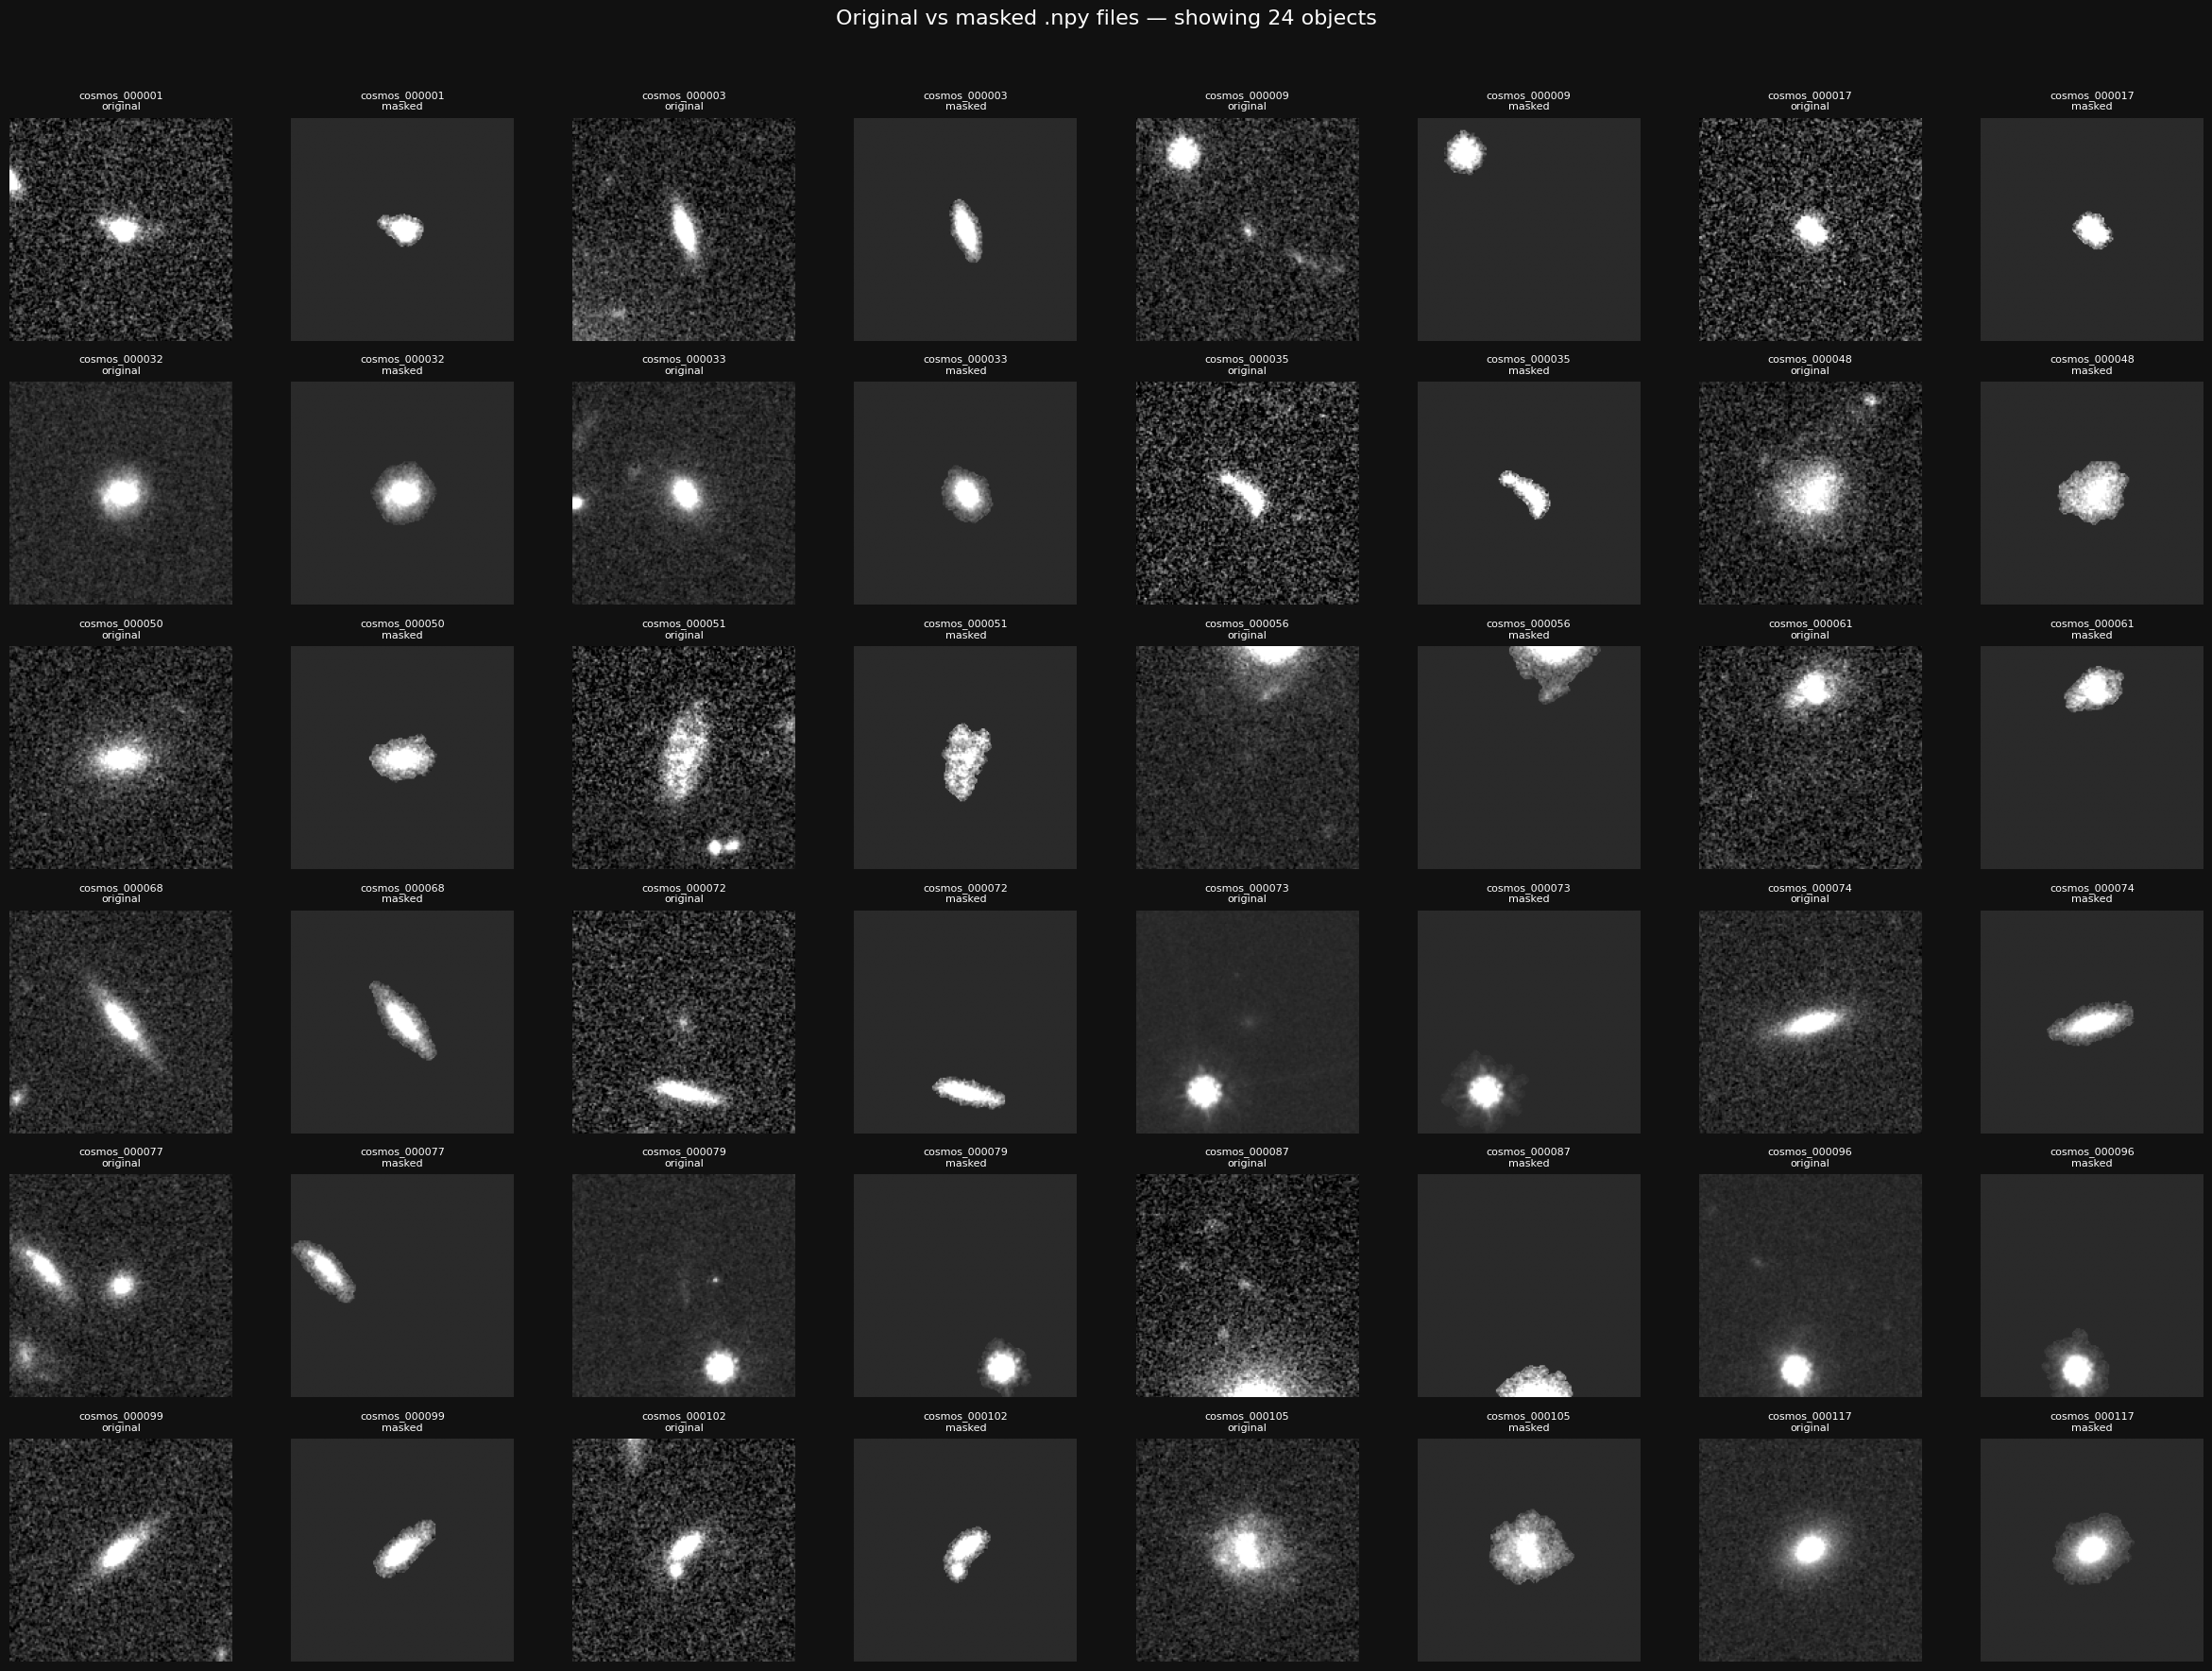

In [11]:
# Visualize exported .npy and masked .npy files side by side
MAX_SHOW = 24
VMIN = -0.2
VMAX = 1.0

orig_dir = NPYDIR
masked_dir = MASKEDNPYDIR

orig_files = sorted(orig_dir.glob("*.npy"))
masked_files = sorted(masked_dir.glob("*.npy")) if masked_dir.exists() else []

print(f"Original .npy directory: {orig_dir.resolve()}")
print(f"Masked .npy directory:   {masked_dir.resolve()}")
print(f"Found {len(orig_files)} original .npy files")
print(f"Found {len(masked_files)} masked .npy files")

if len(orig_files) == 0:
    print("No original .npy files found.")
else:
    stems = [fp.stem for fp in orig_files[:MAX_SHOW]]
    ncols = 4 if len(masked_files) > 0 else 6
    nrows = math.ceil(len(stems) / ncols)

    if len(masked_files) > 0:
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=2 * ncols,
            figsize=(3.0 * 2 * ncols, 3.0 * nrows),
            facecolor="#111111",
        )
        axes = np.array(axes).reshape(nrows, 2 * ncols)

        for ax in axes.ravel():
            ax.set_facecolor("#111111")
            ax.axis("off")

        for i, stem in enumerate(stems):
            r = i // ncols
            c = i % ncols

            ax1 = axes[r, 2 * c]
            ax2 = axes[r, 2 * c + 1]

            orig = np.load(orig_dir / f"{stem}.npy")
            ax1.imshow(orig, cmap="gray", origin="lower", vmin=VMIN, vmax=VMAX)
            ax1.set_title(f"{stem}\noriginal", color="white", fontsize=8)
            ax1.axis("off")

            masked_path = masked_dir / f"{stem}.npy"
            if masked_path.exists():
                masked = np.load(masked_path)
                ax2.imshow(masked, cmap="gray", origin="lower", vmin=VMIN, vmax=VMAX)
                ax2.set_title(f"{stem}\nmasked", color="white", fontsize=8)
            else:
                ax2.text(0.5, 0.5, "no masked file", color="white", ha="center", va="center", fontsize=9)
                ax2.set_title(f"{stem}\nmasked", color="white", fontsize=8)
            ax2.axis("off")

        fig.suptitle(
            f"Original vs masked .npy files — showing {len(stems)} objects",
            color="white",
            fontsize=16,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    else:
        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(2.8 * ncols, 2.8 * nrows),
            facecolor="#111111",
        )
        axes = np.array(axes).reshape(nrows, ncols)

        for ax in axes.ravel():
            ax.set_facecolor("#111111")
            ax.axis("off")

        for i, stem in enumerate(stems):
            r = i // ncols
            c = i % ncols
            ax = axes[r, c]

            arr = np.load(orig_dir / f"{stem}.npy")
            ax.imshow(arr, cmap="gray", origin="lower", vmin=VMIN, vmax=VMAX)
            ax.set_title(stem, color="white", fontsize=8)
            ax.axis("off")

        fig.suptitle(
            f"Original .npy files — showing {len(stems)} objects",
            color="white",
            fontsize=16,
        )
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

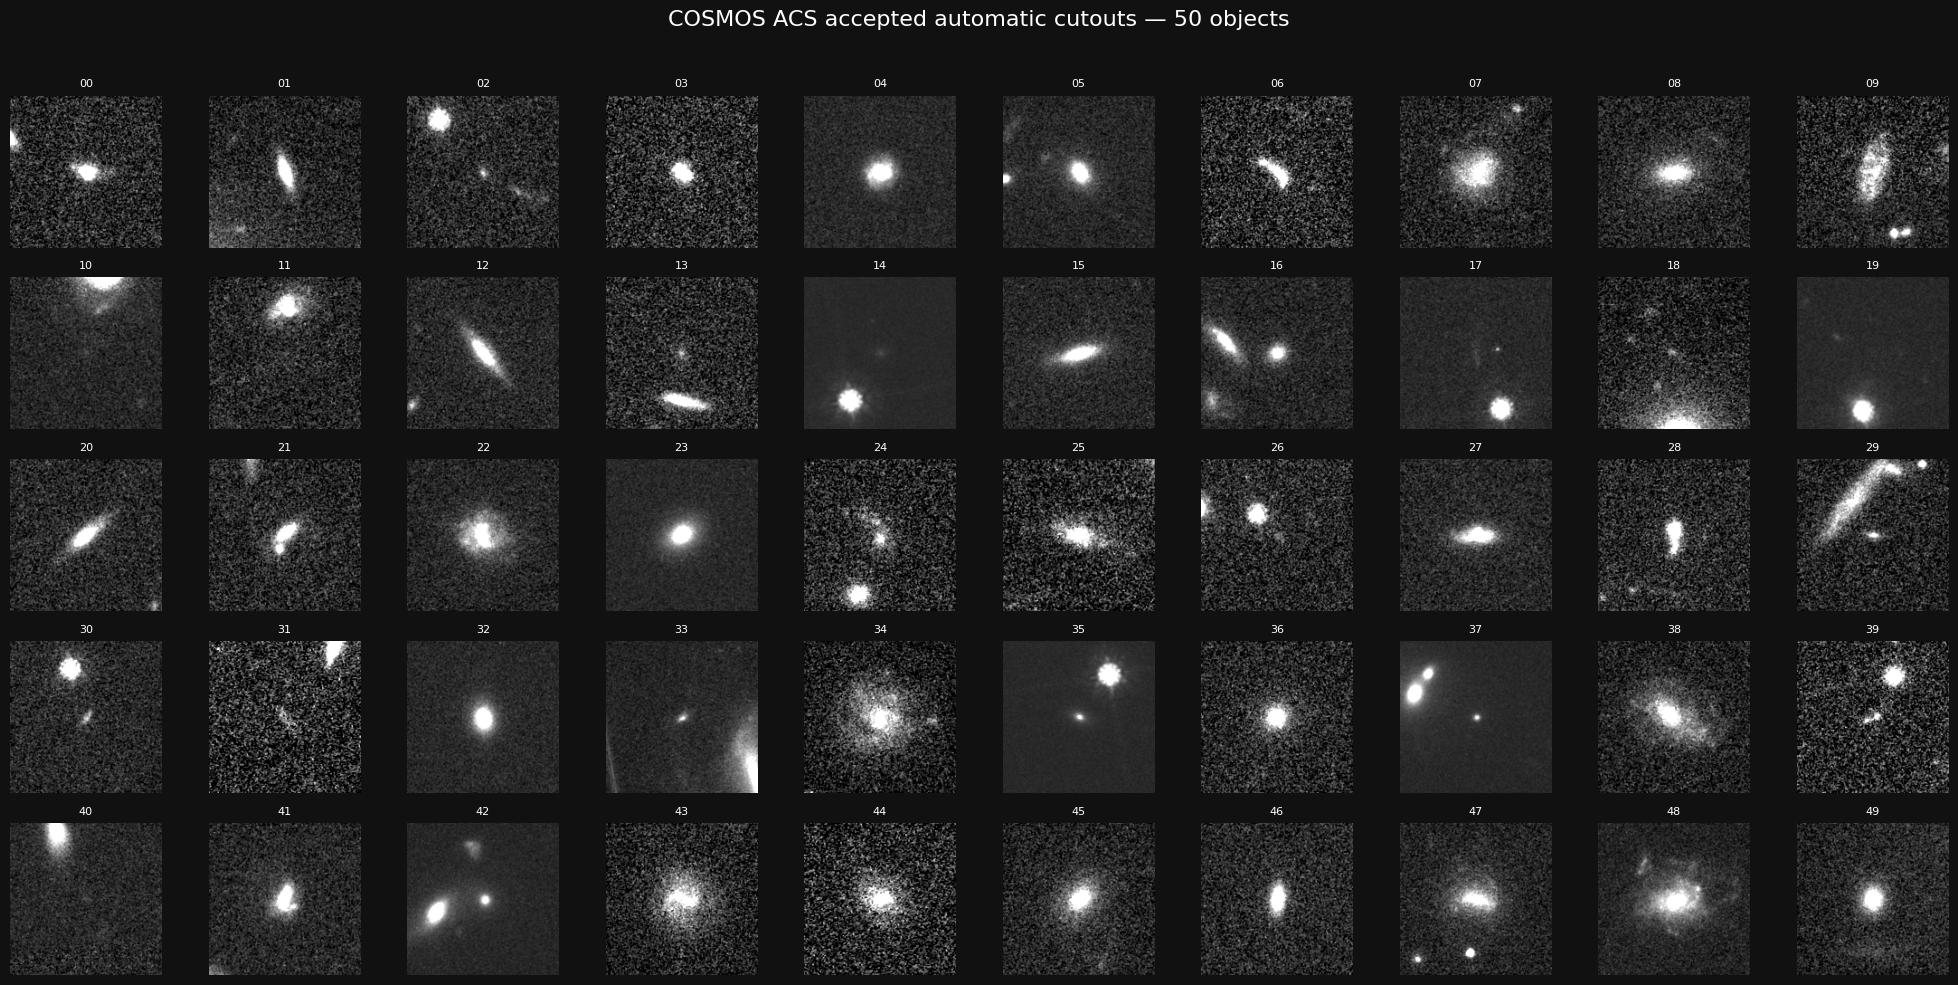

Saved grid to C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\qa_plots\galaxy_grid.jpg


In [12]:
# Summary plot of accepted cutouts
if len(accepted_df) == 0:
    print("No accepted cutouts available for plotting.")
else:
    accepted_names = accepted_df["source_id"].tolist()
    num_accept = len(accepted_names)

    ncols = 10
    nrows = math.ceil(num_accept / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(2.0 * ncols, 2.0 * nrows),
        facecolor="#111111"
    )
    axes = np.array(axes).reshape(nrows, ncols)

    for ax in axes.ravel():
        ax.set_facecolor("#111111")
        ax.axis("off")

    for i, name in enumerate(accepted_names):
        ax = axes.ravel()[i]
        ax.imshow(image_store[name], cmap="gray", origin="lower", vmin=-0.2, vmax=1.0)
        ax.set_title(f"{i:02d}", color="white", fontsize=8)
        ax.axis("off")

    fig.suptitle(
        f"COSMOS ACS accepted automatic cutouts — {num_accept} objects",
        color="white",
        fontsize=16,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    grid_path = PLOTDIR / "galaxy_grid.jpg"
    fig.savefig(grid_path, dpi=180, facecolor=fig.get_facecolor(), bbox_inches="tight")
    plt.show()

    print("Saved grid to", grid_path.resolve())

In [13]:
# Final note for lenstronomy
print("=" * 70)
print("COSMOS IRSA AUTOMATIC CUTOUT EXTRACTION COMPLETE")
print("=" * 70)
print("Accepted cutouts:", len(accepted_df))
print("NumPy arrays:", NPYDIR.resolve())
print("Metadata CSV:", (METADIR / "accepted_cutouts.csv").resolve())
print("Metadata JSON:", (METADIR / "cutout_metadata.json").resolve())
print()
print("For lenstronomy, the main image input is the exported .npy array.")
print("Keep the metadata files as well for provenance, QA, and later filtering.")
print("If EXPORT_MASKED_FOR_LENSTRONOMY = True, the main .npy export is the masked version.")
print("Otherwise the main .npy export is the original normalized cutout.")

COSMOS IRSA AUTOMATIC CUTOUT EXTRACTION COMPLETE
Accepted cutouts: 50
NumPy arrays: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\npy
Metadata CSV: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\metadata\accepted_cutouts.csv
Metadata JSON: C:\Users\upraj\Prajwal\GSOC\DeepLense\DeepLense_Unsupervised_Super_Resolution_Prajwal_Uday\cosmos_irsa_auto\metadata\cutout_metadata.json

For lenstronomy, the main image input is the exported .npy array.
Keep the metadata files as well for provenance, QA, and later filtering.
If EXPORT_MASKED_FOR_LENSTRONOMY = True, the main .npy export is the masked version.
Otherwise the main .npy export is the original normalized cutout.
